### step1 : Import libraries 

In [14]:
# Import libraries for reading and manipulating data
import pandas as pd
# Import library for numerical operations
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import utilities for performance evaluation
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# Import utilities for data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Import libraries for assumption testing
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
import scipy.stats as stats

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')


In [4]:
data = pd.read_csv('content/insurance_charges.csv')

### step 2 : Data Visualization

In [10]:
data.shape
data.head()
# Display column names, data types and no.of rows in the dataset
data.info()

data.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   children  1338 non-null   int64  
 2   smoker    1338 non-null   str    
 3   region    1338 non-null   str    
 4   plan      1338 non-null   str    
 5   charges   1338 non-null   float64
dtypes: float64(1), int64(2), str(3)
memory usage: 84.7 KB


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0,27.000,39.000,51.000,64.00
children,1338.0,1.094918,1.205493,0.0,0.000,1.000,2.000,5.00
charges,1338.0,9852.747511,3588.235727,500.0,7298.795,9933.295,12479.195,20453.48


In [12]:
data.describe(include='str')

,smoker,region,plan
count,1338,1338,1338
unique,2,4,3
top,no,southeast,Bronze
freq,1064,364,509


### step 3 : PreProcessing

In [13]:
duplicate_rows = data[data.duplicated()]
# Identify duplicate rows
duplicate_rows = data[data.duplicated()]

# Print the number of duplicate rows
print(f"Number of duplicate rows: {len(duplicate_rows)}")

# Drop the duplicate rows if any.

data = data.drop_duplicates()
# Print the shape of the DataFrame after removing duplicates
print(f"Shape after removing duplicates: {data.shape}")

Number of duplicate rows: 0
Shape after removing duplicates: (1338, 6)


### step 2.a : Exploratory Data Analysis

#### step 2.1 : Univariate Analysis


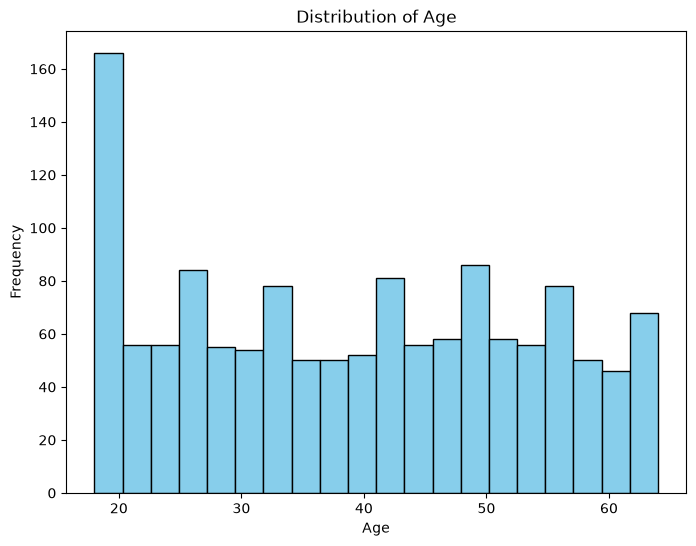

In [27]:
# Histogram of age
plt.figure(figsize=(8, 6))
plt.hist(data['age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

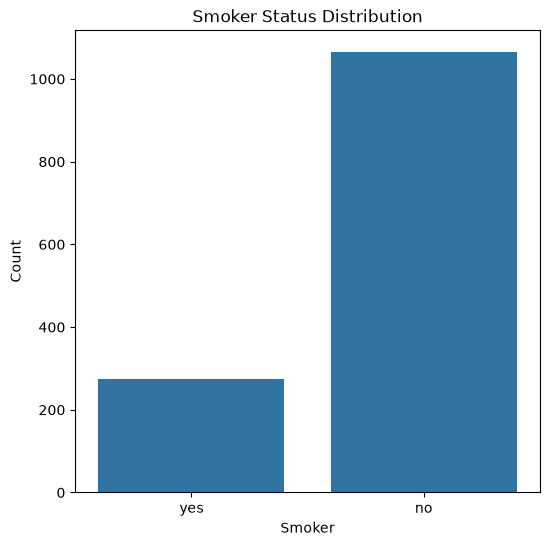

In [28]:
# Distribution of smoker status
plt.figure(figsize=(6, 6))
sns.countplot(x='smoker', data=data)
plt.title('Smoker Status Distribution')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.show()

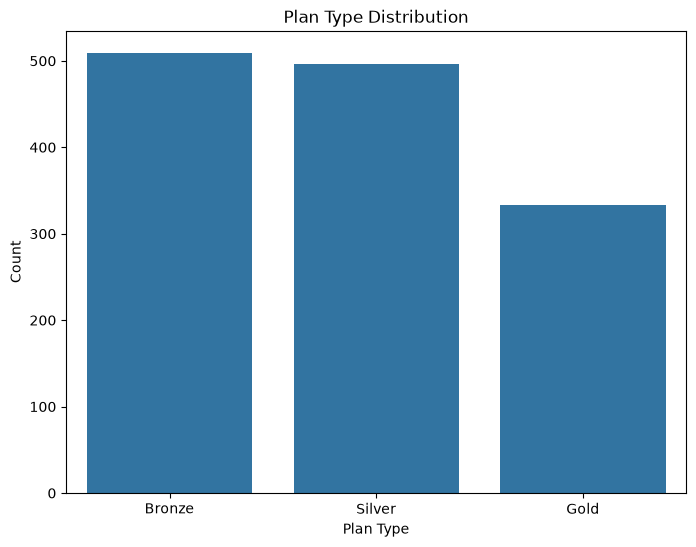

In [29]:
# Distribution of plan type
plt.figure(figsize=(8, 6))
sns.countplot(x='plan', data=data, order=['Bronze', 'Silver', 'Gold'])
plt.title('Plan Type Distribution')
plt.xlabel('Plan Type')
plt.ylabel('Count')
plt.show()

#### step 2.2 : Bivariate Analysis


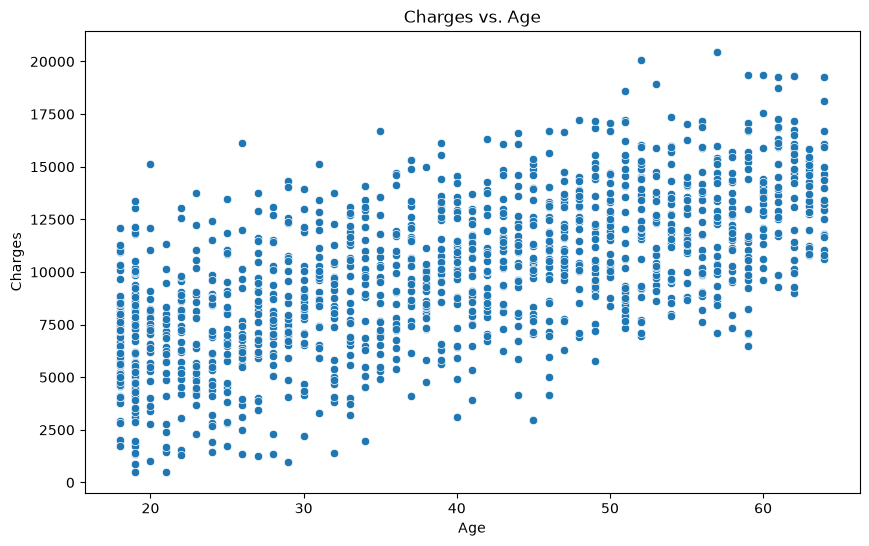

In [30]:
# Scatter plot of charges vs age
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', data=data)
plt.title('Charges vs. Age')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

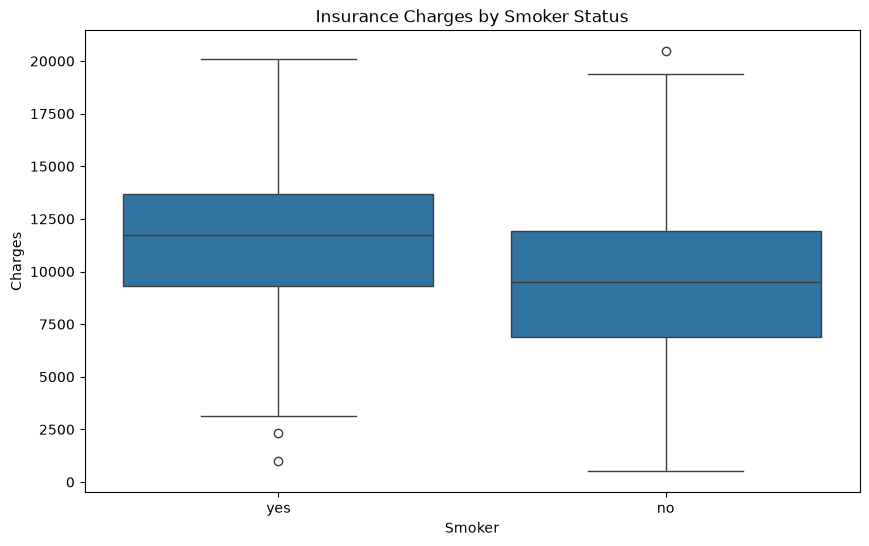

In [31]:
# Compare charges for smokers vs. non-smokers
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=data)
plt.title('Insurance Charges by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

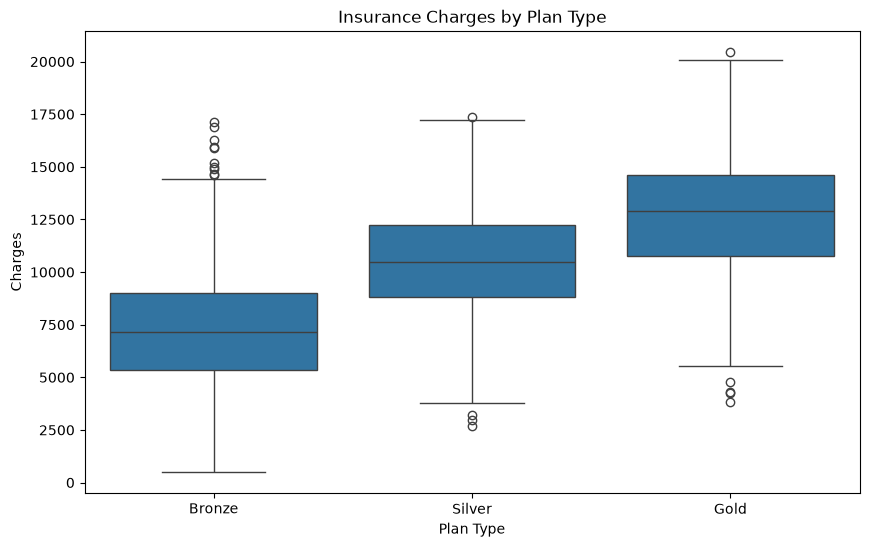

In [32]:
# Visualize how insurance charges vary with plan type.
plt.figure(figsize=(10, 6))
sns.boxplot(x='plan', y='charges', data=data, order=['Bronze', 'Silver', 'Gold'])
plt.title('Insurance Charges by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Charges')
plt.show()

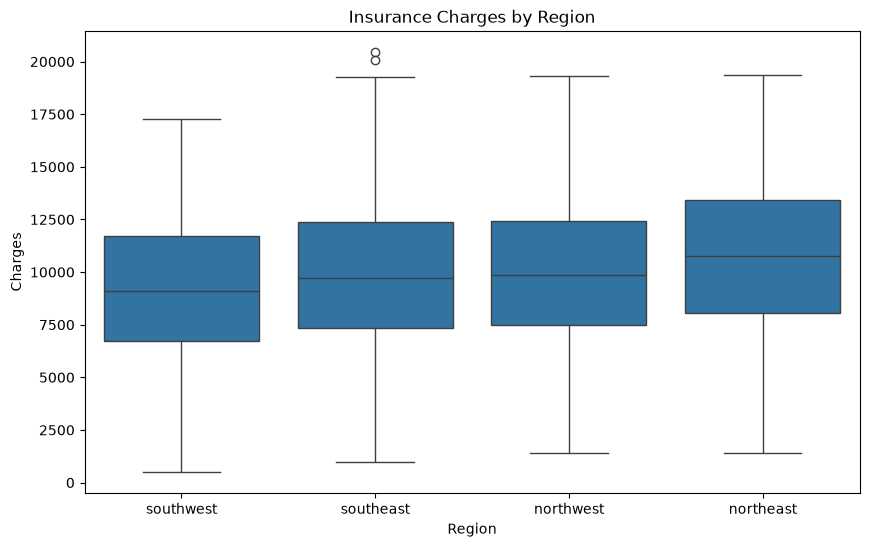

In [33]:
# Visualize how insurance charges vary with region.
plt.figure(figsize=(10, 6))
sns.boxplot(x='region', y='charges', data=data)
plt.title('Insurance Charges by Region')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.show()

### Correlation Heatmap


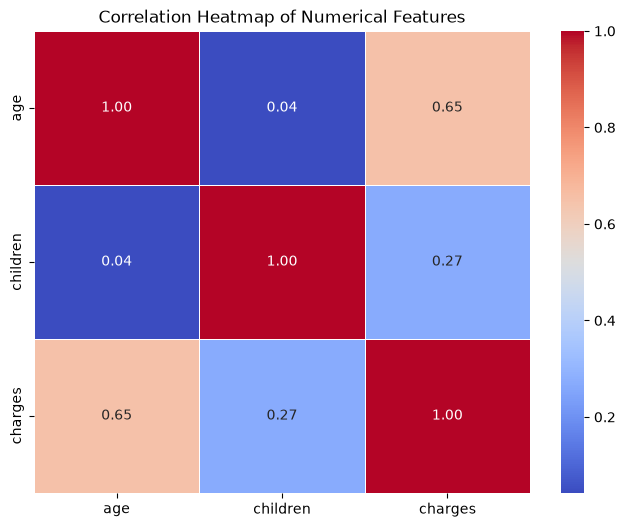

In [23]:
# Correlation matrix for numerical features
numerical_cols = ['age', 'children', 'charges']
correlation_matrix = data[numerical_cols].corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Step 3 : Data Preprocessing
To begin, we aim to build three linear regression models:

In the first model, we use only the age column to build a Simple Linear Regression model.
In the second model, we use only the numerical features (age, children) to build a Multiple Linear Regression model.
In the third model, we use all features including the encoded categorical ones.
Before that, we need to encode the categorical variables.

#### Encode the Data


In [ ]:
# This is one-hot encoding for categorical variables, which is necessary for regression models that require numerical input.
# drop_first=True is used to avoid the dummy variable trap, which can lead to multicollinearity in regression models. 
# For example if I have 100 categories, I only need to create 99 dummy variables, as the last category can be inferred from the others.
# We use dtype=int in dummy encoding to guarantee that the output is numerical (0 and 1), as it may otherwise default to Boolean values (True and False).

data = pd.get_dummies(
    data, 
    columns=['smoker', 'region', 'plan'], 
    drop_first=True, 
    dtype=int)
# We don't use ordinal encoding here because the categorical variables do not have a natural order. For example, 'region' and 'plan' are nominal categories, and 'smoker' is binary. 
# Using one-hot encoding allows us to represent these categories without implying any order or hierarchy.

#### Train Test Split


In [36]:
# Split the data into training and testing sets
# Split data into features (X) and target (y)
X = data.drop('charges', axis=1)
y = data['charges']

# Split into training and testing sets (85/15)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [37]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1137, 8)
X_test shape: (201, 8)
y_train shape: (1137,)
y_test shape: (201,)


### Step 4: Model Building
#### Model Evaluation Criterion
##### In insurance price prediction, the model can make two types of mistakes:
###### Underestimating the price - when the predicted premium is lower than it should be.
###### Overestimating the price - when the predicted premium is higher than it should be.

##### We use the following metrics to evaluate model performance:
###### MAPE (Mean Absolute Percentage Error): Average percentage deviation of predictions from actuals; lower is better.
###### RMSE (Root Mean Squared Error): Square root of MSE; in the same unit as the target.
###### R² (R-squared): Proportion of variance in the target explained by the model; closer to 1 is better.


### Utility Functions
##### Define utility functions to simplify OLS model training and prediction throughout the analysis.

In [38]:
# Create a reusable function to fit an OLS regression model, automatically adding an intercept term before training.
# OLS (Ordinary Least Squares) regression is a method for estimating the parameters in a linear regression model.
#  It minimizes the sum of the squared differences between the observed and predicted values. 
# The function below takes in predictor variables (x) and target variable (y), adds a constant term for the intercept, fits the OLS model, and returns the fitted model.

# Linear regression is available in multiple libraries, including scikit-learn and statsmodels(OLS-fit).

def ols_fit(x,y):
    # Add a constant term to the predictor variables for the intercept
    x_with_const = sm.add_constant(x)
    
    # Fit the OLS model
    model = sm.OLS(y, x_with_const).fit()
    
    return model


In [39]:
# Create a reusable function to generate predictions from a trained OLS model, ensuring the intercept term is added to the input data before prediction.
def ols_predict(model, x):
    # Add a constant term to the predictor variables for the intercept
    x_with_const = sm.add_constant(x, has_constant='add')
    
    # Generate predictions
    predictions = model.predict(x_with_const)
    
    return predictions

In [40]:
#  create an empty DataFrame named model_eval_results with columns for model name and training/testing metrics (MAPE, RMSE, and R²).
model_eval_results = pd.DataFrame(
    columns=['Model', 'Train_Mape', 'Train_RMSE', 'Train_R2',
             'Test_Mape', 'Test_RMSE', 'Test_R2']
)

In [45]:
# Next, we define a reusable function to evaluate any model and store its results.
if 'model_eval_results' not in globals():
    model_eval_results = pd.DataFrame(
        columns=['Model', 'Train_Mape', 'Train_RMSE', 'Train_R2',
                 'Test_Mape', 'Test_RMSE', 'Test_R2']
    )

def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    """Evaluates the model on train and test data and appends results to model_eval_results."""
    global model_eval_results

    # Predict on training and testing data
    y_train_pred = ols_predict(model, X_train)
    y_test_pred  = ols_predict(model, X_test)

    # Training metrics
    train_mse  = mean_squared_error(y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2   = r2_score(y_train, y_train_pred)

    # Testing metrics
    test_mse  = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_r2   = r2_score(y_test, y_test_pred)

    train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
    test_mape  = mean_absolute_percentage_error(y_test, y_test_pred)

    # Append to results
    model_eval_results.loc[len(model_eval_results)] = [
        model_name,
        round(train_mape, 2), round(train_rmse, 2), round(train_r2, 4),
        round(test_mape,  2), round(test_rmse,  2), round(test_r2,  4)
    ]

    # Print formatted output
    print(f"─── {model_name} ───")
    print(f"  Train  →  Mape: {train_mape:.4f}   RMSE: {train_rmse:>10,.2f}   R²: {train_r2:.4f}")
    print(f"  Test   →  Mape: {test_mape:.4f}   RMSE: {test_rmse:>10,.2f}   R²: {test_r2:.4f}")

    return



### Step 5: Model Building
#### With the data preprocessed and ready, we begin our modeling phase using Ordinary Least Squares (OLS) Regression from statsmodels, a highly interpretable technique for modeling continuous outcomes and understanding the impact of individual predictors.

#### Model 1
##### In the first model, we use only the age feature to demonstrate how simple linear regression works and how it performs.


In [41]:
# Define features (X) and target (y) for Model 1 (Age only)
x_train_m1 = X_train['age']
x_test_m1 = X_test['age']

# Initialize and train the model
model1 = ols_fit(x_train_m1, y_train)

In [43]:
#Display the OLS model summary for Model 2
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.415
Model:                            OLS   Adj. R-squared:                  0.415
Method:                 Least Squares   F-statistic:                     806.6
Date:                Mon, 20 Jul 2026   Prob (F-statistic):          1.75e-134
Time:                        20:12:53   Log-Likelihood:                -10608.
No. Observations:                1137   AIC:                         2.122e+04
Df Residuals:                    1135   BIC:                         2.123e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3483.2415    239.898     14.520      0.000    3012.549    3953.934
age          163.4048      5.754     28.401      0.000     152.116     174.694
==============================================================================
Omnibus:                        2.071   Durbin-Watson:                   2.073
Prob(Omnibus):                  0.355   Jarque-Bera (JB):                2.100
Skew:                           0.076   Prob(JB):                        0.350
Kurtosis:                       2.855   Cond. No.                         124.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [46]:
evaluate_model("Model 1: Age Only", model1, x_train_m1, x_test_m1, y_train, y_test)

# The error is relatively high and the R² value is moderate for both the training and testing datasets, indicating the model is underfitting.
# This is expected because we are using only a single feature.

─── Model 1: Age Only ───
  Train  →  Mape: 0.3428   RMSE:   2,727.82   R²: 0.4154
  Test   →  Mape: 0.3434   RMSE:   2,748.90   R²: 0.4430


### Model2 
#### In the second model, we use the numerical features (age, children) to train a multiple linear regression model.

In [47]:
num_features = ['age','children']
x_train_m2 = X_train[num_features]
x_test_m2 = X_test[num_features]

model2 = ols_fit(x_train_m2, y_train)

In [48]:
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.483
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     530.0
Date:                Mon, 20 Jul 2026   Prob (F-statistic):          3.12e-163
Time:                        20:16:52   Log-Likelihood:                -10538.
No. Observations:                1137   AIC:                         2.108e+04
Df Residuals:                    1134   BIC:                         2.110e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2796.4268    232.613     12.022      0.000    2340.026    3252.828
age          159.5498      5.422     29.427      0.000     148.912     170.188
children     765.4180     62.813     12.186      0.000     642.176     888.660
==============================================================================
Omnibus:                        1.233   Durbin-Watson:                   2.088
Prob(Omnibus):                  0.540   Jarque-Bera (JB):                1.307
Skew:                           0.071   Prob(JB):                        0.520
Kurtosis:                       2.913   Cond. No.                         128.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [50]:
evaluate_model('Model 2 (Numerical Features)', model2, x_train_m2, x_test_m2, y_train, y_test)

─── Model 2 (Numerical Features) ───
  Train  →  Mape: 0.3159   RMSE:   2,565.04   R²: 0.4831
  Test   →  Mape: 0.3290   RMSE:   2,723.81   R²: 0.4531


### Model 3
#### use the entire dataset, including all numerical and encoded categorical features to build our final multiple linear regression model.

In [52]:
# Initialize and train the Linear Regression model on all features
model3 = ols_fit(X_train, y_train)

In [54]:
print(model3.summary())


                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.604
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     215.3
Date:                Mon, 20 Jul 2026   Prob (F-statistic):          5.83e-221
Time:                        20:18:33   Log-Likelihood:                -10387.
No. Observations:                1137   AIC:                         2.079e+04
Df Residuals:                    1128   BIC:                         2.084e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             3358.4995    242.460  

In [55]:
evaluate_model("Model 3: All Features", model3, X_train, X_test, y_train, y_test)

─── Model 3: All Features ───
  Train  →  Mape: 0.2711   RMSE:   2,244.41   R²: 0.6043
  Test   →  Mape: 0.2613   RMSE:   2,170.74   R²: 0.6527


In [56]:
model_eval_results

,Model,Train_Mape,Train_RMSE,Train_R2,Test_Mape,Test_RMSE,Test_R2
0,Model 1: Age Only,0.34,2727.82,0.4154,0.34,2748.90,0.4430
1,Model 2 (Numerical Features),0.32,2565.04,0.4831,0.33,2723.81,0.4531
2,Model 3: All Features,0.27,2244.41,0.6043,0.26,2170.74,0.6527


Testing Linear Regression Assumptions
For a linear regression model to be reliable, the following assumptions must hold:

#	Assumption	How to test
1	Linearity	Residuals vs Fitted plot - points should scatter randomly around zero
2	Normality of Residuals	Q-Q plot + Shapiro-Wilk test
3	Homoscedasticity (constant variance of residuals)	Scale-Location plot + Breusch-Pagan test
4	No Autocorrelation of residuals	Durbin-Watson statistic (should be ≈ 2)
5	No Multicollinearity between features	Variance Inflation Factor (VIF) - should be < 5
We define each assumption as a modular function, so we can re-run them if needed.

### Modular Assumption Functions


In [57]:
# Residuals vs Fitted plot
def test_linearity(y_true, y_pred, title_suffix=''):
    """Plots residuals vs fitted values to check for linearity."""
    residuals = y_true - y_pred

    plt.figure(figsize=(8, 5))
    plt.scatter(y_pred, residuals, alpha=0.4, color='steelblue')
    plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
    plt.xlabel('Fitted Values')
    plt.ylabel('Residuals')
    plt.title(f'1. Linearity - Residuals vs Fitted {title_suffix}')
    plt.show()

    print("✔ Interpretation:")
    print("  • If residuals scatter randomly around 0, linearity holds.")
    print("  • A clear curve or pattern indicates non-linearity.")

In [58]:
# normality of residuals (Q-Q plot + Shapiro-Wilk test)
# We limit the Shapiro-Wilk test to a maximum of 3,000 residuals because, with very large samples, 
# the test tends to flag even minor and practically unimportant deviations from normality, making the results less meaningful for model assessment.
def test_normality(y_true, y_pred, title_suffix=''):
    """Checks normality of residuals via Q-Q plot and Shapiro-Wilk test."""
    residuals = y_true - y_pred

    # Q-Q plot
    plt.figure(figsize=(8, 5))
    stats.probplot(residuals, dist='norm', plot=plt)
    plt.title(f'2. Normality - Q-Q Plot {title_suffix}')
    plt.show()

    # Shapiro-Wilk test
    sample = residuals.sample(min(3000, len(residuals)), random_state=42) \
             if hasattr(residuals, 'sample') else residuals[:3000]
    stat, p = stats.shapiro(sample)

    print("✔ Shapiro-Wilk Test:")
    print(f"  W-statistic = {stat:.4f}")
    print(f"  p-value     = {p:.4f}")
    if p > 0.05:
        print("  → Residuals are approximately normal (p > 0.05) ✅")
    else:
        print("  → Residuals deviate from normality (p ≤ 0.05) ⚠️")
        print("  → Note: With large samples, minor deviations are flagged; the Q-Q plot is the more practical guide.")

In [59]:
# function to test the homoscedasticity assumption (Scale-Location plot + Breusch-Pagan test).
def test_homoscedasticity(y_true, y_pred, X, title_suffix=''):
    """Checks homoscedasticity via Scale-Location plot and Breusch-Pagan test."""
    residuals = y_true - y_pred

    # Scale-Location plot
    plt.figure(figsize=(8, 5))
    plt.scatter(y_pred, np.sqrt(np.abs(residuals)), alpha=0.4, color='green')
    plt.xlabel('Fitted Values')
    plt.ylabel('√|Residuals|')
    plt.title(f'3. Homoscedasticity - Scale-Location Plot {title_suffix}')
    plt.show()

    # Breusch-Pagan test
    bp_test = sms.het_breuschpagan(residuals, sm.add_constant(X))
    print("✔ Breusch-Pagan Test:")
    print(f"  LM-statistic = {bp_test[0]:.4f}")
    print(f"  p-value      = {bp_test[1]:.4f}")
    if bp_test[1] > 0.05:
        print("  → Variance of residuals is constant - homoscedasticity holds ✅")
    else:
        print("  → Heteroscedasticity detected (p ≤ 0.05) ⚠️")

In [60]:
#function to test autocorrelation of residuals (Durbin-Watson statistic).
def test_autocorrelation(y_true, y_pred):
    """Checks for autocorrelation of residuals via Durbin-Watson statistic."""
    residuals = y_true - y_pred
    dw = durbin_watson(residuals)

    print("✔ Durbin-Watson Test:")
    print(f"  DW-statistic = {dw:.4f}")
    if 1.5 < dw < 2.5:
        print("  → No autocorrelation (DW ≈ 2) ✅")
    else:
        print("  → Possible autocorrelation detected ⚠️")

In [62]:
#function to test multicollinearity using Variance Inflation Factor (VIF).
def test_multicollinearity(X):
    """Calculates VIF for each feature to detect multicollinearity."""
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X.columns
    vif_data['VIF']     = [variance_inflation_factor(X.values, i)
                            for i in range(X.shape[1])]
    vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

    print("✔ Variance Inflation Factor (VIF):")
    print(vif_data.to_string(index=False))
    print()
    print("  Interpretation:")
    print("  • VIF < 5   → No multicollinearity issue ✅")
    print("  • 5 ≤ VIF < 10 → Moderate multicollinearity ⚠️")
    print("  • VIF ≥ 10  → High multicollinearity ❌")

    # Visualize
    plt.figure(figsize=(10, 6))
    colors = ['#e74c3c' if v >= 10 else '#f39c12' if v >= 5 else '#2ecc71'
              for v in vif_data['VIF']]
    plt.barh(vif_data['Feature'], vif_data['VIF'], color=colors)
    plt.axvline(5,  color='orange', linestyle='--', linewidth=1, label='VIF = 5')
    plt.axvline(10, color='red',    linestyle='--', linewidth=1, label='VIF = 10')
    plt.xlabel('VIF')
    plt.title('Multicollinearity - VIF per Feature')
    plt.legend()
    plt.gca().invert_yaxis()
    plt.show()

    return vif_data

VIF is computed on the training data because multicollinearity is a property of the predictors used to fit the model, whereas linearity, normality, and homoscedasticity are assessed on test-set residuals to evaluate how well the model's assumptions hold on unseen data.

In [63]:
def check_all_assumptions(model, X_train, X_test, y_train, y_test, label=''):
    """Runs all five linear regression assumption tests on a given fitted model."""
    y_test_pred = ols_predict(model, X_test)

    print("=" * 70)
    print(f"  ASSUMPTION CHECK - {label}")
    print("=" * 70)

    test_linearity(y_test, y_test_pred, title_suffix=f'({label})')
    print()
    test_normality(y_test, y_test_pred, title_suffix=f'({label})')
    print()
    test_homoscedasticity(y_test, y_test_pred, X_test, title_suffix=f'({label})')
    print()
    test_autocorrelation(y_test, y_test_pred)
    print()
    vif_result = test_multicollinearity(X_train)

    print("=" * 70)
    print(f"  END OF ASSUMPTION CHECK - {label}")
    print("=" * 70)
    return vif_result


#### Check Assumptions on Model 3 (All Features)


  ASSUMPTION CHECK - Model 3 - All Features


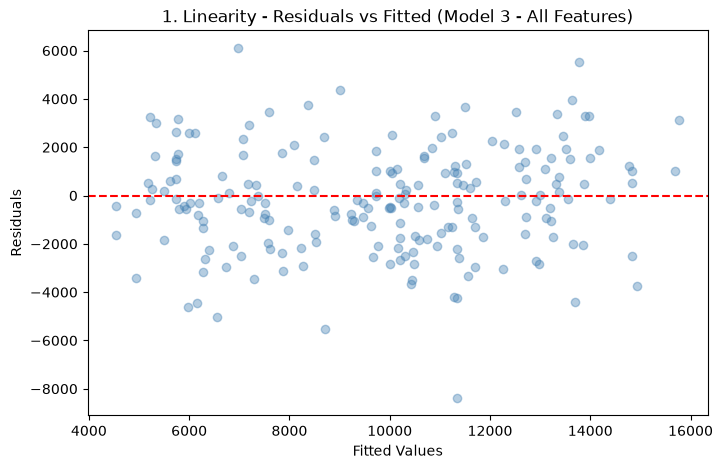

✔ Interpretation:
  • If residuals scatter randomly around 0, linearity holds.
  • A clear curve or pattern indicates non-linearity.



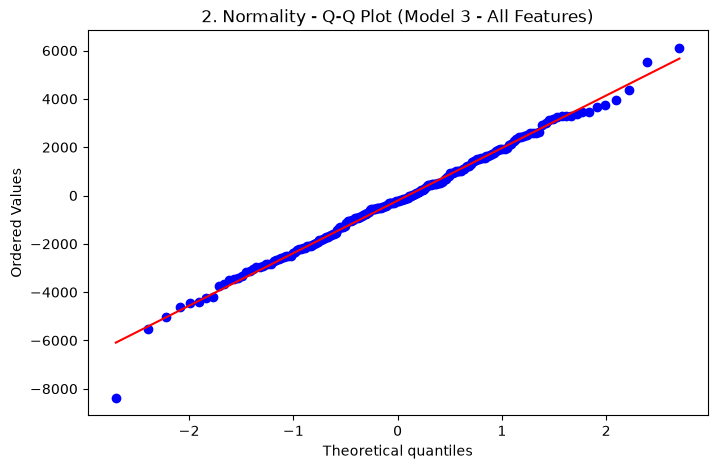

✔ Shapiro-Wilk Test:
  W-statistic = 0.9943
  p-value     = 0.6441
  → Residuals are approximately normal (p > 0.05) ✅



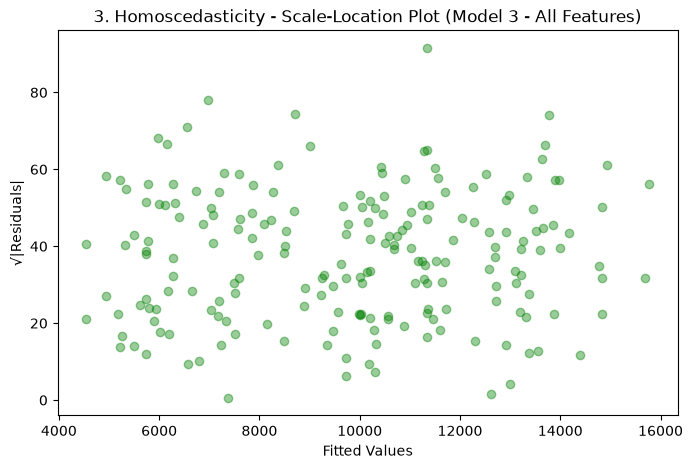

✔ Breusch-Pagan Test:
  LM-statistic = 6.8570
  p-value      = 0.5521
  → Variance of residuals is constant - homoscedasticity holds ✅

✔ Durbin-Watson Test:
  DW-statistic = 1.7023
  → No autocorrelation (DW ≈ 2) ✅

✔ Variance Inflation Factor (VIF):
         Feature      VIF
             age 6.758521
     plan_Silver 2.827601
       plan_Gold 2.595021
        children 1.993932
region_southeast 1.817246
region_southwest 1.740658
region_northwest 1.705716
      smoker_yes 1.229249

  Interpretation:
  • VIF < 5   → No multicollinearity issue ✅
  • 5 ≤ VIF < 10 → Moderate multicollinearity ⚠️
  • VIF ≥ 10  → High multicollinearity ❌


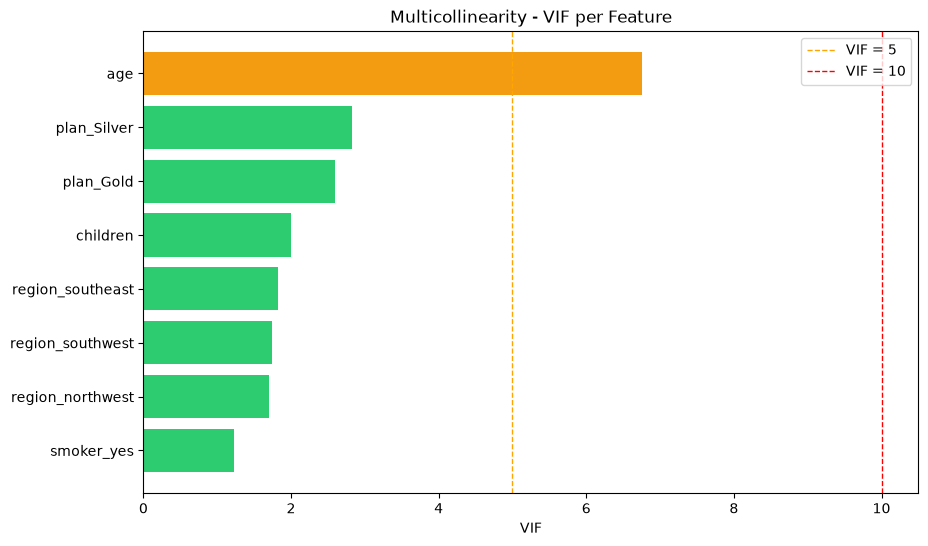

  END OF ASSUMPTION CHECK - Model 3 - All Features


In [64]:
vif_model_3 = check_all_assumptions(
    model3, X_train, X_test, y_train, y_test,
    label='Model 3 - All Features'
)

### End-to-End Pricing Prediction

In [65]:
# Get user input helpers
def get_int_input(prompt, min_value=None, max_value=None):
    while True:
        value = input(prompt).strip()
        if not value:
            print("Input cannot be blank. Please enter a number.")
            continue
        try:
            number = int(value)
        except ValueError:
            print("Invalid integer. Please try again.")
            continue
        if min_value is not None and number < min_value:
            print(f"Value must be at least {min_value}.")
            continue
        if max_value is not None and number > max_value:
            print(f"Value must be at most {max_value}.")
            continue
        return number

def get_choice_input(prompt, valid_choices):
    valid_map = {choice.lower(): choice for choice in valid_choices}
    while True:
        value = input(prompt).strip().lower()
        if not value:
            print("Input cannot be blank. Please choose one of:", ", ".join(valid_choices))
            continue
        if value in valid_map:
            return valid_map[value]
        print("Invalid choice. Please enter one of:", ", ".join(valid_choices))

def predict_premium(age, children, smoker, region, plan):
    input_data = pd.DataFrame(0, index=[0], columns=X_train.columns)

    input_data['age'] = age
    input_data['children'] = children

    if smoker.lower() == 'yes':
        input_data['smoker_yes'] = 1

    if region.lower() == 'northwest':
        input_data['region_northwest'] = 1
    elif region.lower() == 'southeast':
        input_data['region_southeast'] = 1
    elif region.lower() == 'southwest':
        input_data['region_southwest'] = 1

    if plan.lower() == 'gold':
        input_data['plan_Gold'] = 1
    elif plan.lower() == 'silver':
        input_data['plan_Silver'] = 1

    predicted_charge = ols_predict(model3, input_data)[0]
    return predicted_charge

print("Enter the details to predict the annual premium:")

user_age = get_int_input("Enter age (e.g., 30): ", min_value=0)
user_children = get_int_input("Enter number of children (e.g., 1): ", min_value=0)
user_smoker = get_choice_input("Is the person a smoker? (yes/no): ", ['yes', 'no'])
user_region = get_choice_input(
    "Enter region (northeast, northwest, southeast, or southwest): ",
    ['northeast', 'northwest', 'southeast', 'southwest']
)
user_plan = get_choice_input(
    "Enter plan type (bronze, silver, or gold): ",
    ['bronze', 'silver', 'gold']
)

predicted_premium = predict_premium(user_age, user_children, user_smoker, user_region, user_plan)
print(f"\nPredicted annual premium: ${predicted_premium:.2f}")

Enter the details to predict the annual premium:


ValueError: invalid literal for int() with base 10: ''